In [128]:
import os 
import pandas as pd 
import numpy as np
import re
import math
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import igraph

from thefuzz import process
from lingpy import * # We're just importing everything from lingpy for simplicity
from lingpy import Wordlist, LexStat, Alignments, Tree, SCA # This is just to track that we used lingly module for these functions
from lingpy.sequence.sound_classes import ipa2tokens
from lingpy.compare.sanity import average_coverage, mutual_coverage_check, synonymy
from lingpy.convert.cldf import to_cldf
from datetime import datetime
from itertools import combinations
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from tabulate import tabulate
from shapely.geometry import Point
from collections import Counter, defaultdict
from pathlib import Path

In [129]:
# Folder name in current directory where all files (Excel, images, etc. will be saved)
results_folder_name = 'Pipeline results'

In [130]:
king_data=pd.read_excel('data/King et al 200 item list synchronised w OCSEAN.xlsx', sheet_name='King IDs match Ocsean concepts')
king_data = king_data[king_data['ID King et al'].notna()]
king_data = king_data[king_data['Concept Ocsean'].notna()]
king_data = king_data.iloc[:, :3]
king_data.columns = ["Index","King ID", "Ocsean ID"]
king_data.head()

,Index,King ID,Ocsean ID
0,5-1,hand,hand
2,5-2,left,left (side)
3,5-3,right,right (side)
4,5-4,legfoot,foot
6,5-5,towalk,walk


In [131]:
## read the data into pandas dataframe
df_semantic = pd.read_csv('Pipeline results/OCSEAN_processed_joineddata_semantic.tsv', sep='\t')
df_semantic.head()

,Concept,Word,Language,IPA,Semantic_Field
0,sun,wariy,Abui_Bunggeta,wariy,The physical world
1,moon,ʔuya,Abui_Bunggeta,ʔuya,The physical world
2,star,furiy,Abui_Bunggeta,furiy,The physical world
3,sky,ʔadiiy,Abui_Bunggeta,ʔadiiy,The physical world
4,earth,buku,Abui_Bunggeta,buku,NaN


In [132]:
# Check which 'Ocsean ID' values are present in df_semantic['Concept']
present_mask = king_data['Ocsean ID'].isin(df_semantic['Concept'])

# Print summary
print(f"{present_mask.sum()} out of {len(king_data)} King IDs found in df_semantic['Concept'].")
print("Missing King IDs:")
print(king_data.loc[~present_mask, 'Ocsean ID'].tolist())

208 out of 208 King IDs found in df_semantic['Concept'].
Missing King IDs:
[]


In [133]:
king_semantic=df_semantic[df_semantic['Concept'].isin(king_data['Ocsean ID'])]

# Show the first few rows of the merged dataframe
king_semantic.head()

,Concept,Word,Language,IPA,Semantic_Field
1,moon,ʔuya,Abui_Bunggeta,ʔuya,The physical world
2,star,furiy,Abui_Bunggeta,furiy,The physical world
3,sky,ʔadiiy,Abui_Bunggeta,ʔadiiy,The physical world
6,cloud,taboqi,Abui_Bunggeta,taboqi,The physical world
7,wind,simooi,Abui_Bunggeta,simooi,The physical world


In [134]:
# Export the DataFrame to an Excel file in the results folder
# Construct the full path to the output file
file_name = 'OCSEAN_processed_joineddata_kingconcepts_semantic.tsv'
output_file_path = os.path.join(results_folder_name, file_name)

try:
    king_semantic.to_csv(output_file_path, sep='\t', index=False) # index=False prevents writing DataFrame index to Excel
    print(f"File '{file_name}' exported successfully to '{results_folder_name}' folder.")
except Exception as e:
    print(f"An error occurred during export: {e}")

File 'OCSEAN_processed_joineddata_kingconcepts_semantic.tsv' exported successfully to 'Pipeline results' folder.


In [135]:
def load_and_validate_data(input_folder,joineddata_filename):
    """Load the initial wordlist data and perform basic validation."""
    print("=" * 50)
    print("STEP 1: Loading and validating wordlist data")
    print("=" * 50)

    # Construct the full path to the file
    file_path = os.path.join(input_folder, joineddata_filename)

    # Load wordlist using LingPy
    # Ensure the file_path exists before trying to load it
    if not os.path.exists(file_path):
        print(f"Error: File not found at {file_path}")
        return None # Or raise an error
    
    wordlist = Wordlist(file_path)
    print(f"Loaded wordlist with {len(wordlist)} entries\n")

    # Create LexStat object for cognate detection
    lexstat = LexStat(wordlist, merge_vowels=True, check=True)
    print("LexStat object created successfully")

    # Display sample data
    print("\nSample data (first 4 entries):")
    # Check if lexstat has enough entries before trying to access them
    num_entries = min(len(lexstat), 4)
    if num_entries > 0:
        print(tabulate([lexstat[idx] for idx in range(1, num_entries + 1)]))
    else:
        print("No entries to display.")

    return lexstat

In [136]:
king_lexstat_object = load_and_validate_data(results_folder_name, joineddata_filename='OCSEAN_processed_joineddata_kingconcepts_semantic.tsv')

STEP 1: Loading and validating wordlist data
Loaded wordlist with 16486 entries



2025-09-18 21:19:23,526 [INFO] No obvious errors found in the data.


LexStat object created successfully

Sample data (first 4 entries):
-----  ------  -------------  ------  ------------------  ------------------------------  ------------------  ------  ------  -  ------------------------------------------------------  --------------------------------  -
moon   ʔuya    Abui_Bunggeta  ʔuya    The physical world  ['ʔ', 'uya']                    [1, 7]              AX      HY      1  ['1.H.C', '1.Y.V']                                      [2.0, 1.5]                        0
star   furiy   Abui_Bunggeta  furiy   The physical world  ['f', 'u', 'r', 'iy']           [3, 7, 5, 7]        AXBZ    BYRI    1  ['1.B.C', '1.Y.V', '1.R.C', '1.I.V']                    [2.0, 1.5, 1.75, 0.8]             0
sky    ʔadiiy  Abui_Bunggeta  ʔadiiy  The physical world  ['ʔ', 'a', 'd', 'iiy']          [1, 7, 1, 7]        AXBZ    HATI    1  ['1.H.C', '1.A.V', '1.T.C', '1.I.V']                    [2.0, 1.5, 1.75, 0.8]             0
cloud  taboqi  Abui_Bunggeta  taboqi  The physic

In [137]:
def detect_cognates(results_folder_name,lexstat_object, cognate_threshold=None, export_filename=None, verbose=False):
    """Detect cognate sets using LexStat algorithm.
    
    Args:
        lexstat_object: LexStat object with loaded wordlist data
        cognate_threshold: Threshold for cognate detection (default: 0.55)
        export_filename: Base filename for output (default: 'detect_cognates_function_results')
        verbose: If True, shows detailed progress. If False, suppresses output.
    """
    print("\n" + "=" * 50)
    print("STEP 3: Detecting cognate sets")
    print("=" * 50)
    
    # Use default values if not provided
    if cognate_threshold is None:
        cognate_threshold = 0.55
    if export_filename is None:
        export_filename = 'detect_cognates_function_results.tsv'
    
    # Get scorer for cognate detection
    print("Computing sound correspondence patterns...")
    
    # Check if scorer already exists and force recalculation if needed
    force_scorer = False
    if hasattr(lexstat_object, 'cscorer') and lexstat_object.cscorer is not None:
        if verbose:
            print("Existing scorer found, forcing recalculation...")
        force_scorer = True
    
    try:
        if verbose:
            # Show detailed progress including correspondence calculations
            lexstat_object.get_scorer(force=force_scorer)
        else:
            # Suppress verbose output using LingPy's built-in verbosity control
            import logging
            import os
            
            # Store original settings
            original_level = logging.getLogger('lingpy').level
            original_verbose = os.environ.get('LINGPY_LOG', '')
            
            # Set quiet mode
            logging.getLogger('lingpy').setLevel(logging.ERROR)
            os.environ['LINGPY_LOG'] = 'ERROR'
            
            try:
                # Use LingPy's progress bar suppression if available
                try:
                    from lingpy.settings import rcParams
                    original_progress = rcParams.get('verbose', True)
                    rcParams['verbose'] = False
                except:
                    original_progress = None
                
                lexstat_object.get_scorer(force=force_scorer)
                
                # Restore progress setting
                if original_progress is not None:
                    try:
                        rcParams['verbose'] = original_progress
                    except:
                        pass
                        
            finally:
                # Restore original logging settings
                logging.getLogger('lingpy').setLevel(original_level)
                if original_verbose:
                    os.environ['LINGPY_LOG'] = original_verbose
                else:
                    os.environ.pop('LINGPY_LOG', None)
    
    except Exception as e:
        print(f"Error during scorer creation: {e}")
        print("Retrying scorer creation with force=True and verbose output...")
        try:
            lexstat_object.get_scorer(force=True)
        except Exception as e2:
            print(f"Scorer creation failed again: {e2}")
            raise RuntimeError("Unable to create scorer for cognate detection") from e2
    
    # Verify scorer was created successfully
    if not hasattr(lexstat_object, 'cscorer') or lexstat_object.cscorer is None:
        print("Warning: Scorer creation may have failed. Retrying with verbose output...")
        try:
            lexstat_object.get_scorer(force=True)  # Force recreation with verbose output
        except Exception as e:
            print(f"Final scorer creation attempt failed: {e}")
            raise RuntimeError("Unable to create scorer for cognate detection") from e
        
        # Final check
        if not hasattr(lexstat_object, 'cscorer') or lexstat_object.cscorer is None:
            raise RuntimeError("Scorer creation succeeded but cscorer attribute is still missing")
    
    print("Sound correspondence patterns computed successfully!")
    
    # Verify we have the necessary attributes for clustering
    required_attrs = ['cscorer', '_numbers', '_prostrings']
    missing_attrs = [attr for attr in required_attrs if not hasattr(lexstat_object, attr)]
    if missing_attrs:
        raise RuntimeError(f"LexStat object is missing required attributes: {missing_attrs}")
    
    # Cluster cognates using LexStat with infomap clustering
    print(f"Clustering cognates (threshold: {cognate_threshold})...")
    
    try:
        if verbose:
            lexstat_object.cluster(
                method='lexstat', 
                threshold=cognate_threshold, 
                cluster_method='infomap', 
                ref='cogid'
            )
        else:
            # Suppress clustering progress as well
            import logging
            import os
            
            original_level = logging.getLogger('lingpy').level
            original_verbose = os.environ.get('LINGPY_LOG', '')
            
            logging.getLogger('lingpy').setLevel(logging.ERROR)
            os.environ['LINGPY_LOG'] = 'ERROR'
            
            try:
                # Also try to suppress progress bars
                try:
                    from lingpy.settings import rcParams
                    original_progress = rcParams.get('verbose', True)
                    rcParams['verbose'] = False
                except:
                    original_progress = None
                
                lexstat_object.cluster(
                    method='lexstat', 
                    threshold=cognate_threshold, 
                    cluster_method='infomap', 
                    ref='cogid'
                )
                
                # Restore progress setting
                if original_progress is not None:
                    try:
                        rcParams['verbose'] = original_progress
                    except:
                        pass
                        
            finally:
                logging.getLogger('lingpy').setLevel(original_level)
                if original_verbose:
                    os.environ['LINGPY_LOG'] = original_verbose
                else:
                    os.environ.pop('LINGPY_LOG', None)
    
    except Exception as e:
        print(f"Error during clustering: {e}")
        print("This might be due to data issues or threshold problems.")
        print("Try adjusting the cognate_threshold or checking your data.")
        raise
    
    # Output results to TSV file
    try:
        # Construct the full path for the output TSV file.
        # 'export_filename' should be just the file's name, including its '.tsv' extension
        # (e.g., "my_cognates.tsv" or "report_data.tsv"), without any directory path.
        full_output_path = os.path.join(results_folder_name, export_filename)

        lexstat_object.output('tsv', filename=full_output_path)
        print(f"Cognate results saved to: {full_output_path}")
    except Exception as e:
        print(f"Error saving results: {e}")
        print("Cognate detection completed but file output failed.")

    print("Cognate detection completed successfully!")
    
    return lexstat_object

In [138]:
cognate_threshold = .55
export_filename = 'detect_cognates_function_king_results'

cognates_detected = detect_cognates(results_folder_name,king_lexstat_object, cognate_threshold=cognate_threshold, export_filename=export_filename, verbose=False)


STEP 3: Detecting cognate sets
Computing sound correspondence patterns...


KeyboardInterrupt: 

In [ ]:
lexdf_king=pd.read_table(os.path.join(results_folder_name,'detect_cognates_function_king_results.tsv'),skiprows=2,comment='#')

In [ ]:
def compute_cognate_overlaps_king(results_folder_name):
    """
    Counts the number of cognate words for each language pair and produces two matrices, one for the counts
    and another for the 
    Args:
        results_folder_name: the folder of where to read results from lingpy cognate detection.
    Returns:
        Nothing
    """
    print("\n" + "=" * 50)
    print("STEP 5: Performing sequence alignment and calculating distances")
    print("=" * 50)
    # Get unique list of languages
    lexdf=pd.read_table(os.path.join(results_folder_name,'detect_cognates_function_king_results.tsv'),skiprows=2,comment='#')
    mylanguages = sorted(lexdf['DOCULECT'].unique())
    lang_idx = {lang: i for i, lang in enumerate(mylanguages)}

    # Initialize matrix
    matrix = np.zeros((len(mylanguages), len(mylanguages)), dtype=int)

    # Group by cognate set
    for cogid, group in lexdf.groupby('COGID'):
        langs = group['DOCULECT'].unique()
        for lang1, lang2 in combinations(langs, 2):
            i, j = lang_idx[lang1], lang_idx[lang2]
            matrix[i][j] += 1
            matrix[j][i] += 1  # Because it's undirected

    # Optional: fill diagonal with how many unique cognate sets each language has
    for lang in mylanguages:
        matrix[lang_idx[lang]][lang_idx[lang]] = lexdf[lexdf['DOCULECT'] == lang]['COGID'].nunique()

    # Turn into a pandas DataFrame
    adj_df = pd.DataFrame(matrix, index=mylanguages, columns=mylanguages)
    # Save
    adj_df.to_csv(os.path.join(results_folder_name,'OCSEAN_cognate_adjacency_matrix_king.csv'))
    # Assuming adj_df is a symmetric matrix
    diagonal = np.diag(adj_df)
    scaling_factors = np.sqrt(np.outer(diagonal, diagonal))

    # Element-wise division
    scaled_df = adj_df / scaling_factors

    # Convert back to DataFrame with same labels
    scaled_df = pd.DataFrame(scaled_df, index=adj_df.index, columns=adj_df.columns)
    scaled_df.to_csv(os.path.join(results_folder_name,'OCSEAN_scaled_cognate_adjacency_matrix_king.csv'))

In [ ]:
## Report cognate overlaps
compute_cognate_overlaps_king(results_folder_name)


STEP 5: Performing sequence alignment and calculating distances


In [ ]:
def perform_alignment_and_process_distances(results_folder_name,filename, align_method='library'):
    """
    Performs sequence alignment, calculates distances, and processes the distance matrix.
    Args:
        filename (str): The base filename for the input TSV and output files.
        align_method (str, optional): The alignment method to use. Defaults to 'library'.
    Returns:
        tuple: A tuple containing:
            - alignments (lingpy.Alignments): The alignments object.
            - dist_matrix (pandas.DataFrame): The processed symmetric distance matrix.
    """
    print("\n" + "=" * 50)
    print("STEP 5: Performing sequence alignment and calculating distances")
    print("=" * 50)

    # Construct the full path to the file
    file_path = os.path.join(results_folder_name, f'{filename}.tsv')

    # Load wordlist using LingPy
    # Ensure the file_path exists before trying to load it
    if not os.path.exists(file_path):
        print(f"Error: File not found at {file_path}")
        return None # Or raise an error
    
    # Load data for alignment
    lexstat_proc = LexStat(file_path, check=True)
    
    # Create alignments object
    alignments = Alignments(
        lexstat_proc,
        transcription='WORD',
        ref="COGID",
        segments="segments"
    )
    
    # Perform alignment using library method
    print("Aligning sequences...")
    alignments.align(method=align_method)
    
    # Calculate distance matrix
    print("Calculating distance matrix...")
    distances = alignments.get_distances(ref='cogid')

    alignments.output('dst', filename=os.path.join(results_folder_name,'OCSEAN_processed_distances_king'))
    tdists=pd.read_table(os.path.join(results_folder_name,'OCSEAN_processed_distances_king.dst'),skiprows=1,header=None)

    theaders = list(tdists.iloc[:,0])
    dists  = pd.DataFrame(tdists.values[:,1:], columns=theaders,index=theaders)
    dist_matrix = dists[dists.columns].astype(float)  # or int

    # Display final results
    print(f"\nFinal dist_matrix shape: {dist_matrix.shape}")
    if not dist_matrix.empty:
        print("Final dist_matrix:")
        print(f"Column names: {list(dist_matrix.columns)[:10]}...")  # Show first 10
        
        # Verify the matrix is symmetric (as expected for distance matrices)
        if dist_matrix.shape[0] == dist_matrix.shape[1]:
            is_symmetric = np.allclose(dist_matrix.values, dist_matrix.values.T, rtol=1e-10)
            print(f"Matrix is symmetric: {is_symmetric}\n")
        
    return alignments, dist_matrix

In [ ]:
OCSEAN_processed_alignments_king, OCSEAN_processed_distances_king = perform_alignment_and_process_distances(results_folder_name,filename='detect_cognates_function_king_results', align_method='library')
OCSEAN_processed_distances_king


STEP 5: Performing sequence alignment and calculating distances


2025-09-18 17:12:06,090 [INFO] No obvious errors found in the data.


Aligning sequences...
Calculating distance matrix...


2025-09-18 17:12:20,094 [ERROR] Zero-division error encountered in 'Bali_Aga' and 'Sabu_Seba'.
Traceback (most recent call last):
  File "/Users/madjl/uv/ocsean_venv/lib/python3.12/site-packages/lingpy/basic/ops.py", line 42, in get_score
    return 1 - shared / (wl.height - missing)
               ~~~~~~~^~~~~~~~~~~~~~~~~~~~~~~
ZeroDivisionError: division by zero
2025-09-18 17:12:20,541 [ERROR] Zero-division error encountered in 'Kolibogon' and 'Sabu_Seba'.
Traceback (most recent call last):
  File "/Users/madjl/uv/ocsean_venv/lib/python3.12/site-packages/lingpy/basic/ops.py", line 42, in get_score
    return 1 - shared / (wl.height - missing)
               ~~~~~~~^~~~~~~~~~~~~~~~~~~~~~~
ZeroDivisionError: division by zero
2025-09-18 17:12:20,550 [ERROR] Zero-division error encountered in 'Kupang_Malay' and 'Sabu_Seba'.
Traceback (most recent call last):
  File "/Users/madjl/uv/ocsean_venv/lib/python3.12/site-packages/lingpy/basic/ops.py", line 42, in get_score
    return 1 - shared 


Final dist_matrix shape: (78, 78)
Final dist_matrix:
Column names: ['Abui_Bunggeta', 'Abui_Kilakawada', 'Abui_Mobyetang', 'Abui_Pelman', 'Adang', 'Agta', 'Agusan_Manobo', 'Agutaynen', 'Akeanon', 'Alurung']...
Matrix is symmetric: True



,Abui_Bunggeta,Abui_Kilakawada,Abui_Mobyetang,Abui_Pelman,Adang,Agta,Agusan_Manobo,Agutaynen,Akeanon,Alurung,...,Tagakaulo,Tagbanwa_Central,Talaandig,Tausug,Tboli,Tuwali,Uab_Meto,Umbu-Ungu,Waray,Yakan
Abui_Bunggeta,0.0000,0.1457,0.2060,0.2261,0.8047,0.9833,0.9698,0.9741,0.9749,0.9688,...,0.9602,0.9692,0.9593,0.9677,0.9745,0.9711,0.9891,0.9742,0.9695,0.9590
Abui_Kilakawada,0.1457,0.0000,0.2563,0.2613,0.8125,0.9833,0.9799,0.9741,0.9799,0.9766,...,0.9830,0.9846,0.9651,0.9785,0.9898,0.9827,0.9837,0.9794,0.9848,0.9744
Abui_Mobyetang,0.2060,0.2563,0.0000,0.1457,0.8125,0.9944,0.9749,0.9793,0.9950,0.9688,...,0.9659,0.9897,0.9651,0.9785,0.9796,0.9884,0.9891,0.9794,0.9848,0.9641
Abui_Pelman,0.2261,0.2613,0.1457,0.0000,0.8125,0.9944,0.9698,0.9793,0.9950,0.9688,...,0.9716,0.9897,0.9651,0.9731,0.9796,0.9884,0.9891,0.9794,0.9848,0.9692
Adang,0.8047,0.8125,0.8125,0.8125,0.0000,0.9512,0.9618,0.9462,0.9695,0.9160,...,0.9520,0.9225,0.9512,0.9077,0.9692,0.9587,0.9597,0.9535,0.9535,0.9453
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Tuwali,0.9711,0.9827,0.9884,0.9884,0.9587,0.6164,0.7303,0.7299,0.6685,0.7521,...,0.7055,0.6379,0.6543,0.7294,0.7684,0.0000,0.8667,0.9769,0.6989,0.7151
Uab_Meto,0.9891,0.9837,0.9891,0.9891,0.9597,0.8605,0.8743,0.8342,0.8429,0.7903,...,0.8439,0.8342,0.8405,0.8362,0.8830,0.8667,0.0000,0.9838,0.8624,0.8495
Umbu-Ungu,0.9742,0.9794,0.9794,0.9794,0.9535,0.9890,0.9950,0.9846,0.9851,0.9922,...,0.9888,0.9898,0.9714,0.9840,0.9949,0.9769,0.9838,0.0000,0.9799,0.9897
Waray,0.9695,0.9848,0.9848,0.9848,0.9535,0.6087,0.4757,0.6080,0.3932,0.7519,...,0.5137,0.5594,0.5706,0.6455,0.7389,0.6989,0.8624,0.9799,0.0000,0.6800


In [ ]:
# Export Distance Matrix
file_name = 'OCSEAN_processed_distance_matrix_king.csv'
output_file_path = os.path.join(results_folder_name, file_name)

try:
    OCSEAN_processed_distances_king.to_csv(output_file_path)
    print(f"File '{file_name}' exported successfully to '{results_folder_name}' folder.")
except Exception as e:
    print(f"An error occurred during export: {e}")

File 'OCSEAN_processed_distance_matrix_king.csv' exported successfully to 'Pipeline results' folder.


In [ ]:
import lingpy as lingpy
def build_phylogenetic_tree(results_folder_name,alignments_results):
    """Build and display phylogenetic tree."""
    print("\n" + "=" * 50)
    print("STEP 7: Building phylogenetic tree")
    print("=" * 50)
    
    # Generate tree using UPGMA method
    treestring=alignments_results.get_tree(ref='cogid', tree_calc='upgma', force=True)
    print(treestring)
    tree = lingpy.Tree(treestring)
    
    print("Phylogenetic tree (ASCII representation):")
    print(tree.asciiArt(compact=True))
    
    # Export
    with open("Pipeline results/ocsean_phylogeny_king.nwk", "w") as f:
        f.write(treestring)
    return tree

In [ ]:
OCSEAN_processed_alignments_king.calculate('tree',tree_calc='upgma',ref='cogid',force=True)
OCSEAN_processed_alignments_king.tree

2025-09-18 20:42:53,902 [INFO] Successfully calculated tree.


Tree("('Sabu_Seba',(('Mawes_Wares',Mawesdai),(Umbu-Ungu,(((('Abui_Bunggeta','Abui_Kilakawada'),('Abui_Mobyetang','Abui_Pelman')),(Mauta,(Adang,(Kelon,Reta)))),('Chabacano_Caviteno',(Enggano,(((Alurung,(('Bali_Aga',Balinese),('Kupang_Malay','Loloan_Malay'))),(('Manubo_Tasaday',(Obo,Tboli)),(Arta,((('Ivatan_Ichbayatan','Ivatan_Isabtangen'),((Agta,Gaddang),(('Ibaloi_Ibaloy',Pangasinan),((Kalinga,(Balangao,(Bontoc,'Kankana_ey'))),(Ilokano,Tuwali))))),((Inabaknon,(Yakan,(('Sinama_Banguingui',Tausug),('Sinama_Sitangkai','Sinama_Tabawan')))),((Bolinao,Sangil),((Meranaw,(Ata,Talaandig)),(Agutaynen,((Molbog,Palawano),((Kolibogon,(Minamanwa,('Agusan_Manobo',(Ati,(Tagakaulo,(Bicolano,(((Cuyunon,((Ilognon,(Hiligaynon,'Hiligaynon_20240802')),(Akeanon,'Kinaray_a'))),((Boholano,Waray),(Kamayo,Sinurigaonon))),(Batak,'Tagbanwa_Central')))))))),((Buhid,Hanunuo),(Kapampangan,(Bulus,'Hattang_Kaye'))))))))))))),('Sabu_Raijua',(('Ba_a',Dela),('Uab_Meto',(Kusa,Manea)))))))))));")

In [ ]:
king_tree_results = build_phylogenetic_tree(results_folder_name,alignments_results=OCSEAN_processed_alignments_king)
king_tree_results

2025-09-18 17:23:08,546 [INFO] Successfully calculated tree.



STEP 7: Building phylogenetic tree
('Sabu_Seba',(('Mawes_Wares',Mawesdai),(Umbu-Ungu,(((('Abui_Bunggeta','Abui_Kilakawada'),('Abui_Mobyetang','Abui_Pelman')),(Mauta,(Adang,(Kelon,Reta)))),('Chabacano_Caviteno',(Enggano,(((Alurung,(('Bali_Aga',Balinese),('Kupang_Malay','Loloan_Malay'))),(('Manubo_Tasaday',(Obo,Tboli)),(Arta,((('Ivatan_Ichbayatan','Ivatan_Isabtangen'),((Agta,Gaddang),(('Ibaloi_Ibaloy',Pangasinan),((Kalinga,(Balangao,(Bontoc,'Kankana_ey'))),(Ilokano,Tuwali))))),((Inabaknon,(Yakan,(('Sinama_Banguingui',Tausug),('Sinama_Sitangkai','Sinama_Tabawan')))),((Bolinao,Sangil),((Meranaw,(Ata,Talaandig)),(Agutaynen,((Molbog,Palawano),((Kolibogon,(Minamanwa,('Agusan_Manobo',(Ati,(Tagakaulo,(Bicolano,(((Cuyunon,((Ilognon,(Hiligaynon,'Hiligaynon_20240802')),(Akeanon,'Kinaray_a'))),((Boholano,Waray),(Kamayo,Sinurigaonon))),(Batak,'Tagbanwa_Central')))))))),((Buhid,Hanunuo),(Kapampangan,(Bulus,'Hattang_Kaye'))))))))))))),('Sabu_Raijua',(('Ba_a',Dela),('Uab_Meto',(Kusa,Manea)))))))))));


Tree("('Sabu_Seba',(('Mawes_Wares',Mawesdai),(Umbu-Ungu,(((('Abui_Bunggeta','Abui_Kilakawada'),('Abui_Mobyetang','Abui_Pelman')),(Mauta,(Adang,(Kelon,Reta)))),('Chabacano_Caviteno',(Enggano,(((Alurung,(('Bali_Aga',Balinese),('Kupang_Malay','Loloan_Malay'))),(('Manubo_Tasaday',(Obo,Tboli)),(Arta,((('Ivatan_Ichbayatan','Ivatan_Isabtangen'),((Agta,Gaddang),(('Ibaloi_Ibaloy',Pangasinan),((Kalinga,(Balangao,(Bontoc,'Kankana_ey'))),(Ilokano,Tuwali))))),((Inabaknon,(Yakan,(('Sinama_Banguingui',Tausug),('Sinama_Sitangkai','Sinama_Tabawan')))),((Bolinao,Sangil),((Meranaw,(Ata,Talaandig)),(Agutaynen,((Molbog,Palawano),((Kolibogon,(Minamanwa,('Agusan_Manobo',(Ati,(Tagakaulo,(Bicolano,(((Cuyunon,((Ilognon,(Hiligaynon,'Hiligaynon_20240802')),(Akeanon,'Kinaray_a'))),((Boholano,Waray),(Kamayo,Sinurigaonon))),(Batak,'Tagbanwa_Central')))))))),((Buhid,Hanunuo),(Kapampangan,(Bulus,'Hattang_Kaye'))))))))))))),('Sabu_Raijua',(('Ba_a',Dela),('Uab_Meto',(Kusa,Manea)))))))))));")

In [ ]:
## Read the two trees and compare them
with open("Pipeline results/ocsean_phylogeny.nwk") as f:
    loaded_newick_full = f.read().strip()


with open("Pipeline results/ocsean_phylogeny_king.nwk") as f:
    loaded_newick_king = f.read().strip()

print(loaded_newick_full[:200])  # preview first 200 chars
print(loaded_newick_king[:200])  # preview first 200 chars
toytree_full = toytree.tree(loaded_newick_full)
toytree_king = toytree.tree(loaded_newick_king)


(('Mawes_Wares',Mawesdai),((Mauta,((('Abui_Bunggeta','Abui_Kilakawada'),('Abui_Mobyetang','Abui_Pelman')),(Kelon,(Adang,Reta)))),(Umbu-Ungu,((('Ba_a',Dela),('Uab_Meto',(Kusa,Manea))),(('Sabu_Raijua','
('Sabu_Seba',(('Mawes_Wares',Mawesdai),(Umbu-Ungu,(((('Abui_Bunggeta','Abui_Kilakawada'),('Abui_Mobyetang','Abui_Pelman')),(Mauta,(Adang,(Kelon,Reta)))),('Chabacano_Caviteno',(Enggano,(((Alurung,(('Ba


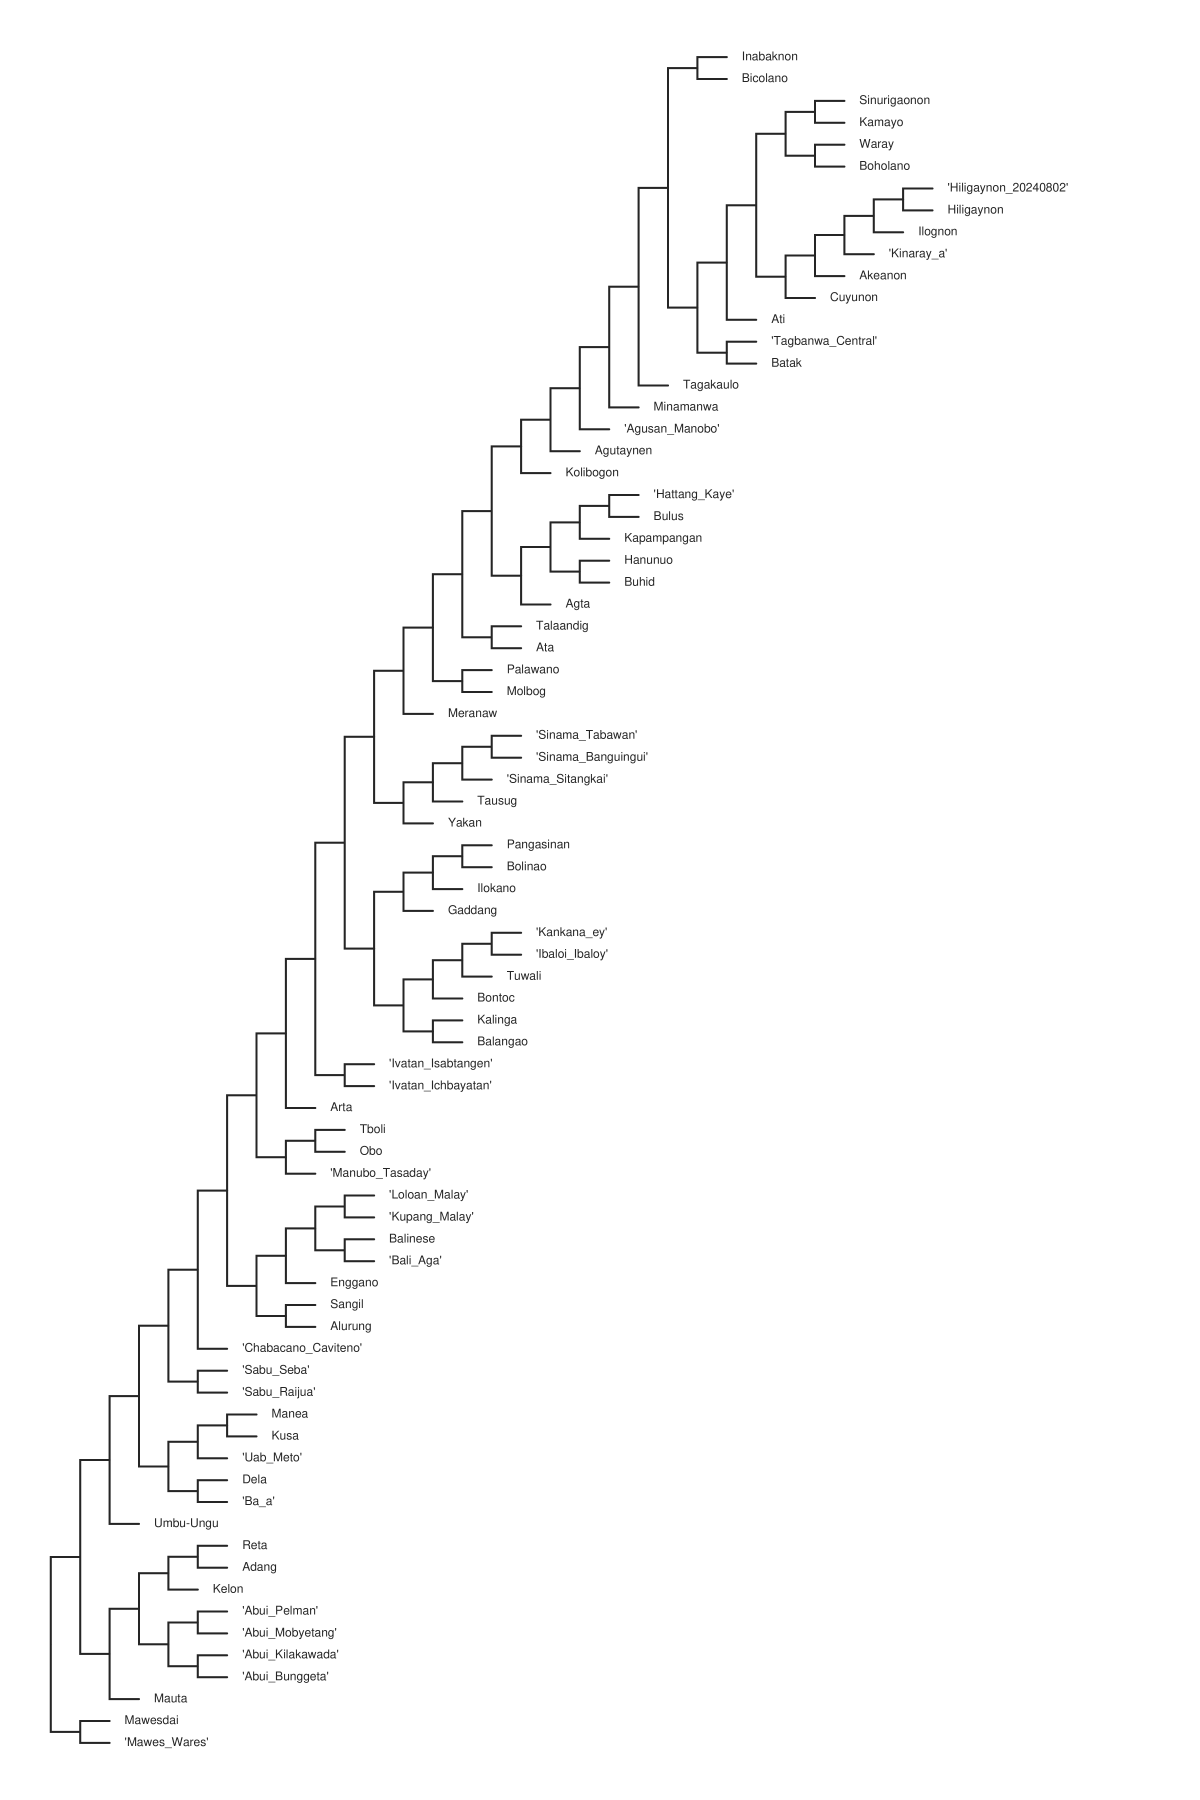

In [ ]:
import toytree
import toyplot.svg
#import toyplot.png
import IPython.display
import xml.etree.ElementTree as ET


tree = toytree.tree(loaded_newick_full)

# Create a toyplot canvas
canvas, axes, mark = tree.draw(width=1200, height=1800)
canvas.style["background-color"] = "white"


# Save as PNG
toyplot.png.render(canvas, "Pipeline results/full_tree.png")

# Show inline in Jupyter / VSCode
png_bytes = toyplot.png.render(canvas)
IPython.display.display(IPython.display.Image(data=png_bytes))

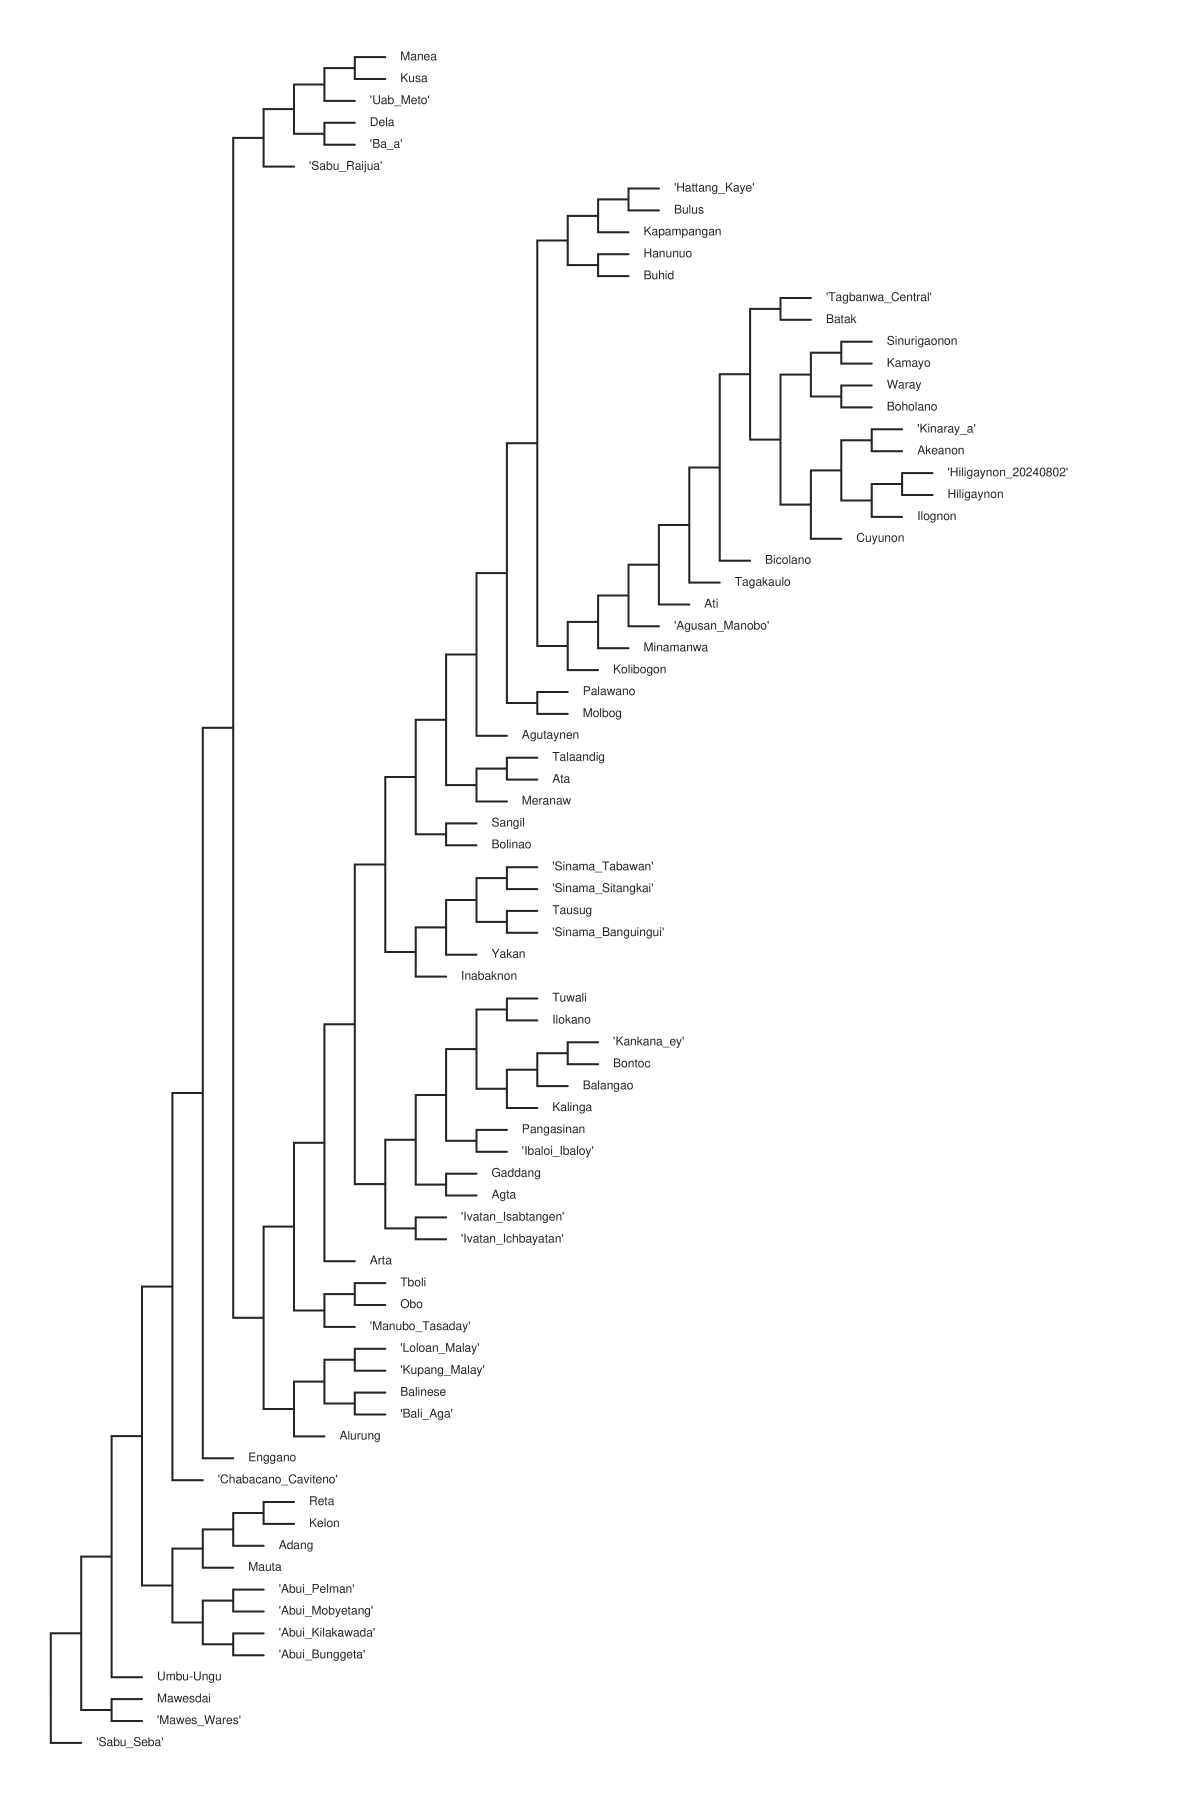

In [ ]:
import toytree
import toyplot.svg
#import toyplot.png
import IPython.display
import xml.etree.ElementTree as ET


tree = toytree.tree(loaded_newick_king)

# Create a toyplot canvas
canvas, axes, mark = tree.draw(width=1200, height=1800)
canvas.style["background-color"] = "white"


# Save as PNG
toyplot.png.render(canvas, "Pipeline results/king_tree.png")

# Show inline in Jupyter / VSCode
png_bytes = toyplot.png.render(canvas)
IPython.display.display(IPython.display.Image(data=png_bytes))

In [ ]:
import dendropy

d_full_tree = dendropy.Tree.get(path="Pipeline results/ocsean_phylogeny.nwk", schema="newick")
d_king_tree = dendropy.Tree.get(path="Pipeline results/ocsean_phylogeny_king.nwk", schema="newick")

rf = ocsean_phylogeny.robinson_foulds_distance(d_king_tree)
print("RF distance:", rf)

In [ ]:
canvas, axes, mark = toytree.draw_tanglegram(toytree_full, toytree_king, width=800, height=600)
canvas.style["background-color"] = "white"
§
toyplot.png.render(canvas, "tanglegram.png", width=800, height=600)
IPython.display.display(IPython.display.Image("tanglegram.png"))

AttributeError: module 'toytree' has no attribute 'draw_tanglegram'

In [ ]:
king_dists=pd.read_csv(os.path.join(results_folder_name,'OCSEAN_processed_distance_matrix_king.csv'),index_col=0)
full_dists=pd.read_csv(os.path.join(results_folder_name,'OCSEAN_processed_distance_matrix.csv'),index_col=0)
king_dists.iloc[0:4,0:4]

,Abui_Bunggeta,Abui_Kilakawada,Abui_Mobyetang,Abui_Pelman
Abui_Bunggeta,0.0000,0.1457,0.2060,0.2261
Abui_Kilakawada,0.1457,0.0000,0.2563,0.2613
Abui_Mobyetang,0.2060,0.2563,0.0000,0.1457
Abui_Pelman,0.2261,0.2613,0.1457,0.0000


In [144]:
import statsmodels.api as sm

# Make sure the rows/columns are aligned
king_dists = king_dists.loc[full_dists.index, full_dists.columns]

# Flatten upper triangle (excluding diagonal) to 1D arrays
mask = np.triu(np.ones(king_dists.shape), k=1).astype(bool)
x = king_dists.values[mask]
y = full_dists.values[mask]


# king_dists: square dataframe, labels in index/columns
labels = king_dists.index.tolist()
n = len(labels)
row_idx, col_idx = np.triu_indices(n, k=1)  # k=1 skips diagonal
pairs = [(labels[i], labels[j]) for i,j in zip(row_idx, col_idx)]



In [ ]:
# Fit LOWESS curve
lowess = sm.nonparametric.lowess
z = lowess(y, x, frac=0.3)  # frac=0.3 controls smoothing span


In [140]:
x_fit, y_fit = z[:,0], z[:,1]
from scipy.spatial import cKDTree

# Build a KD-tree of LOWESS points for fast nearest neighbor search
tree = cKDTree(np.column_stack((x_fit, y_fit)))

# Query nearest point on LOWESS curve for each (x_i, y_i)
distances, idx = tree.query(np.column_stack((x, y)), k=1)

# distances now contains the Euclidean distance to the LOWESS line

In [145]:
threshold = np.percentile(distances, 99)  # top 1% farthest
outliers = np.where(distances >= threshold)[0]
outlier_pairs = [pairs[i] for i in outliers]

# Optional: put in a DataFrame with distances
df_outliers = pd.DataFrame({
    "tip1": [pairs[i][0] for i in outliers],
    "tip2": [pairs[i][1] for i in outliers],
    "king_dist": x[outliers],
    "full_dist": y[outliers]
})

print(df_outliers)

                   tip1                 tip2  king_dist  full_dist
0                 Adang            Sabu_Seba     1.0000     0.8000
1                  Agta            Sabu_Seba     1.0000     0.7931
2               Akeanon   Chabacano_Caviteno     0.8913     0.7492
3                  Ba_a            Sabu_Seba     1.0000     0.8205
4              Balangao            Sabu_Seba     1.0000     0.8438
5              Bali_Aga              Enggano     0.8868     0.7629
6                 Batak               Sangil     0.5000     0.7796
7               Bolinao            Sabu_Seba     1.0000     0.8438
8    Chabacano_Caviteno              Cuyunon     0.9071     0.7621
9    Chabacano_Caviteno              Hanunuo     0.9396     0.8116
10   Chabacano_Caviteno           Hiligaynon     0.9096     0.8054
11   Chabacano_Caviteno  Hiligaynon_20240802     0.8953     0.7907
12   Chabacano_Caviteno              Ilognon     0.9034     0.7701
13   Chabacano_Caviteno            Inabaknon     0.8913     0.

In [148]:
!uv pip install adjustText

Using Python 3.12.7 environment at /Users/madjl/uv/ocsean_venv
Resolved 13 packages in 387ms                                        
Installed 1 package in 16ms                                 
 + adjusttext==1.3.0


2025-09-24 20:27:07,243 [WARNING] Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


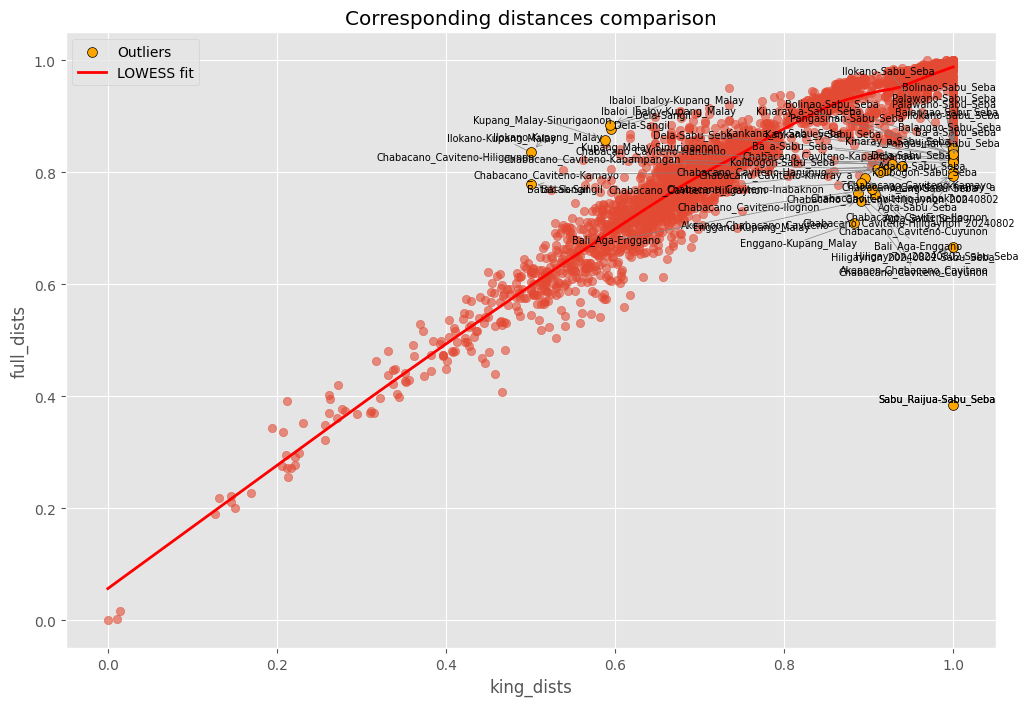

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from adjustText import adjust_text


# Scatter plot
plt.figure(figsize=(12,8))
plt.scatter(x, y, alpha=0.6)

# Highlight outliers
plt.scatter(x[outliers], y[outliers], color='orange', edgecolor='black', s=50, label='Outliers')

plt.xlabel("king_dists")
plt.ylabel("full_dists")
plt.title("Corresponding distances comparison")
plt.grid(True)

plt.plot(z[:,0], z[:,1], color='red', lw=2, label='LOWESS fit')

# Create text objects
texts = []
for _, row in df_outliers.iterrows():
    pair_name = f"{row['tip1']}-{row['tip2']}"
    texts.append(plt.text(row['king_dist'], row['full_dist'], pair_name, fontsize=7))
# Adjust text positions automatically
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5))
plt.legend()

plt.show()

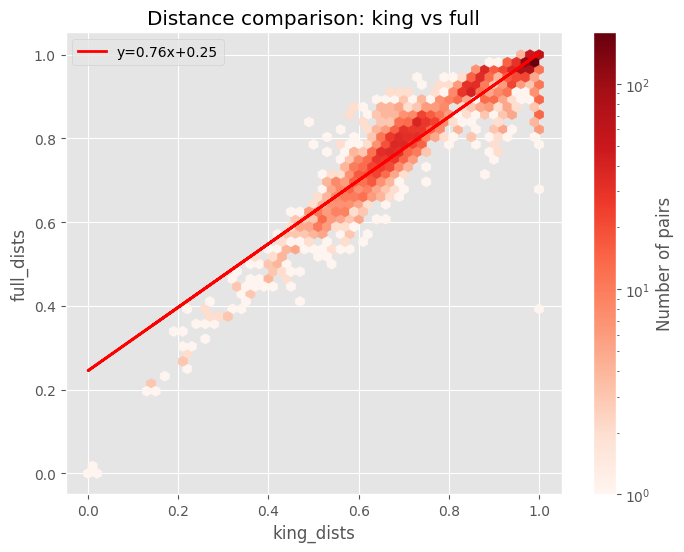

In [124]:

# Create hexbin plot
plt.figure(figsize=(8,6))
hb = plt.hexbin(x, y, gridsize=50, cmap='Reds', mincnt=1,bins='log')  # mincnt=1 avoids empty bins
plt.colorbar(hb, label='Number of pairs')
plt.xlabel('king_dists')
plt.ylabel('full_dists')
plt.title('Distance comparison: king vs full')
plt.grid(True)

# Optional: add correlation line
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red', lw=2, label=f'y={m:.2f}x+{b:.2f}')
plt.legend()

plt.show()

In [ ]:
?tg

Signature:
tg.untangle(
    link1,
    link2,
    labels1,
    labels2,
    method='random',
    L=1.5,
    **kwargs,
)
Docstring:
Untangle two dendrograms using various methods.

Parameters
----------
link1,link2 :       scipy.cluster.hierarchy.linkage
                    Linkages to untangle.
labels1,labels2 :   list
                    Labels for link1 and link2, respectively.
method :            "random" | "step1side" | "step2side" | "permuations"
                    Method to use for untangling. In order of increasing
                    run-time:
                      - "random" shuffles the dendrograms ``R`` times
                      - "step1side" turns every hinge in ``link1`` and
                        keeps ``link2`` fix
                      - "step2side" turns every hinge in both dendrograms
                      - "permutations" runs permutations of rotations for
                        both dendrograms (has ``O(n^2)^2`` complexity)
**kwargs
                    Passed t

INFO  : Generating linkage from distances (tanglegram.tangle)
2025-09-18 20:50:04,301 [INFO] Generating linkage from distances
INFO  : Generating linkage from distances (tanglegram.tangle)
2025-09-18 20:50:04,303 [INFO] Generating linkage from distances
INFO  : Finished optimising at entanglement 0.23 (tanglegram.tangle)
2025-09-18 20:50:04,353 [INFO] Finished optimising at entanglement 0.23
INFO  : Done. Use matplotlib.pyplot.show() to show plot. (tanglegram.tangle)
2025-09-18 20:50:04,435 [INFO] Done. Use matplotlib.pyplot.show() to show plot.


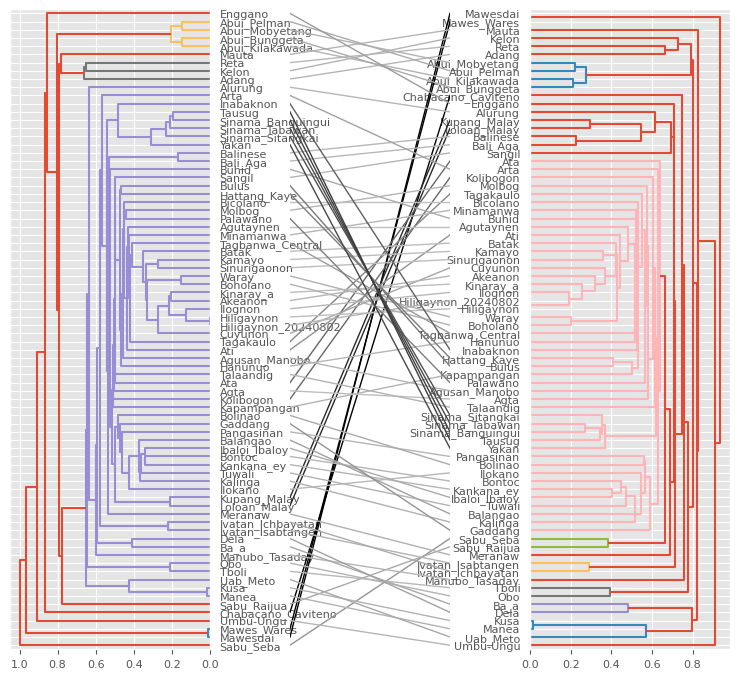

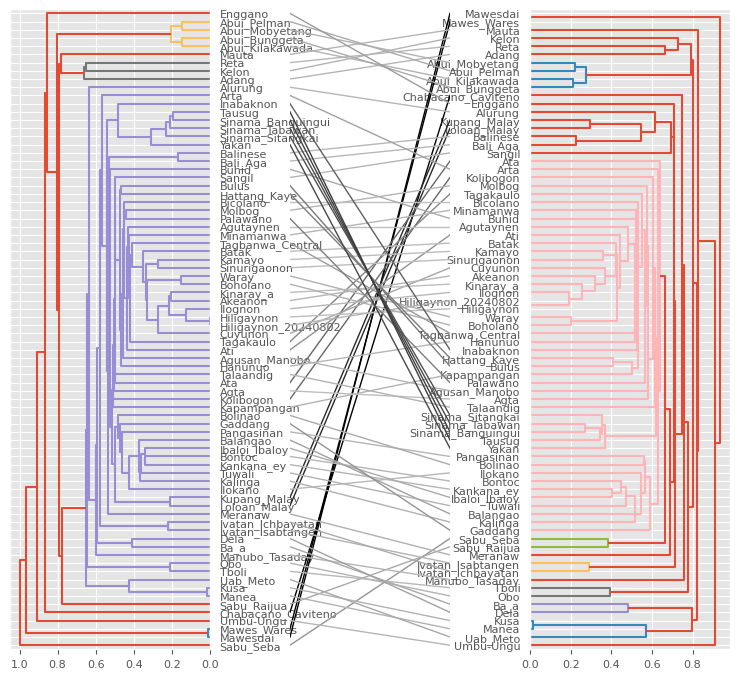

In [118]:
import tanglegram as tg
tg.plot(king_dists, full_dists,sort=True)